# PMF, CDF, Joint Distribution
### CA2 @ EPS Course

#### Instructors: Dr. Tavassolipour, Dr. Vahabie

---

### Instructions:
-  Replace the placeholders (between <font color="green">`## TODO ##`</font> and <font color="green">`## TODO ##`</font>) with the appropriate details.
- Ensure you run each cell after you've entered your solution.

---

*Full Name:* Amirmohammad Mirhosseini

*SID:* 810102601

The objective of this notebook is to understand the concepts of PMF and CDF and joint distribution.

In [38]:
import simpy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Parameters

In [39]:
num_counters = 1
arrival_rate = 5  # customers per minute
service_rate = 6  # customers per minute
simulation_time = 10000  # minutes

## Simulation

In [40]:
def simulate_queue_system():
    """
    Simulates a queue system with customers arriving at service counters, waiting for service, and being served.

    This function defines the customer behavior and the setup of the simulation environment. It initializes the simulation environment, sets up the service counters, and continuously generates customer arrivals based on specified arrival and service rates. The function runs the simulation until the specified simulation time and returns the recorded wait times, arrival times, and service times of the customers.

    Returns:
        tuple: A tuple containing three lists - wait_times, arrival_times, and service_times, which record the respective times for each customer in the simulation.
    """

    def customer(
        env: simpy.Environment,
        name: str,
        counter: simpy.Resource,
        service_time: float,
        wait_times: list,
        arrival_times: list,
        service_times: list,
    ):
        """
        Simulates a customer arriving at a service counter, waiting for service, and then being served.

        Args:
            env (simpy.Environment): The simulation environment.
            name (str): The name of the customer.
            counter (simpy.Resource): The service counter resource.
            service_time (float): The time it takes to serve the customer.
            wait_times (list): A list to record the wait times of customers.
            arrival_times (list): A list to record the arrival times of customers.
            service_times (list): A list to record the service times of customers.

        Yields:
            simpy.events.Process: The process of the customer being served.
        """
        arrival_time = env.now
        arrival_times.append(arrival_time)
        with counter.request() as req:
            yield req
            yield env.timeout(service_time)
            service_times.append(service_time)
            wait_time = env.now - arrival_time
            wait_times.append(wait_time)

    def setup(
        env: simpy.Environment,
        num_counters: int,
        arrival_rate: float,
        service_rate: float,
        wait_times: list,
        arrival_times: list,
        service_times: list,
    ):
        """
        Sets up the simulation environment with a specified number of service counters and customer arrival and service rates.

        Args:
            env (simpy.Environment): The simulation environment.
            num_counters (int): The number of service counters available.
            arrival_rate (float): The rate at which customers arrive.
            service_rate (float): The rate at which customers are served.
            wait_times (list): A list to record the wait times of customers.
            arrival_times (list): A list to record the arrival times of customers.
            service_times (list): A list to record the service times of customers.

        Yields:
            simpy.events.Timeout: The timeout event for the next customer arrival.
        """
        counter = simpy.Resource(env, num_counters)
        while True:
            yield env.timeout(np.random.exponential(1 / arrival_rate))
            service_time = np.random.exponential(1 / service_rate)
            env.process(
                customer(
                    env,
                    "Customer",
                    counter,
                    service_time,
                    wait_times,
                    arrival_times,
                    service_times,
                )
            )

    while True:
        env = simpy.Environment()
        wait_times = []
        arrival_times = []
        service_times = []
        env.process(
            setup(
                env,
                num_counters,
                arrival_rate,
                service_rate,
                wait_times,
                arrival_times,
                service_times,
            )
        )
        env.run(until=simulation_time)

        if len(wait_times) == len(arrival_times) == len(service_times):
            return wait_times, arrival_times, service_times
        
wait_times, arrival_times, service_times = simulate_queue_system()

## Plot the RVs Distributions

Text(0.5, 0, 'arrival_time')

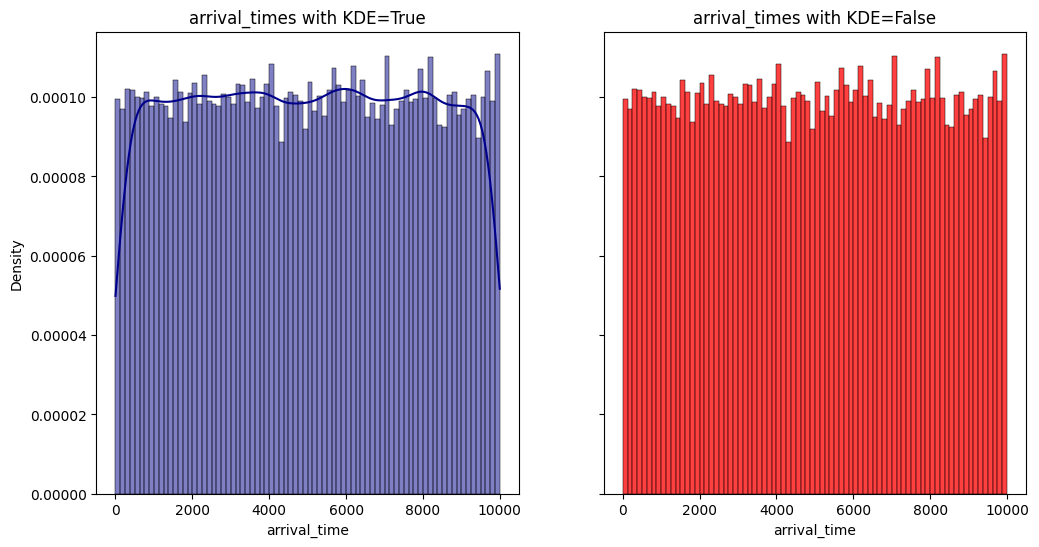

In [41]:
######################  TODO  ########################
# Distribution of Arrival Times
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.histplot(arrival_times, bins=80, kde=1, color='darkblue', stat='density',ax=axes[0])  
axes[0].set_title('arrival_times with KDE=True')
axes[0].set_xlabel('arrival_time')  

sns.histplot(arrival_times, bins=80, kde=0, color='red', stat='density',ax=axes[1])  
axes[1].set_title('arrival_times with KDE=False')
axes[1].set_xlabel('arrival_time')  

#plt.title('arrival_times Distribution')  
#plt.xlabel('arrival_time')  
#plt.ylabel('density')  
######################  TODO  ########################

Text(0.5, 0, 'wait_times')

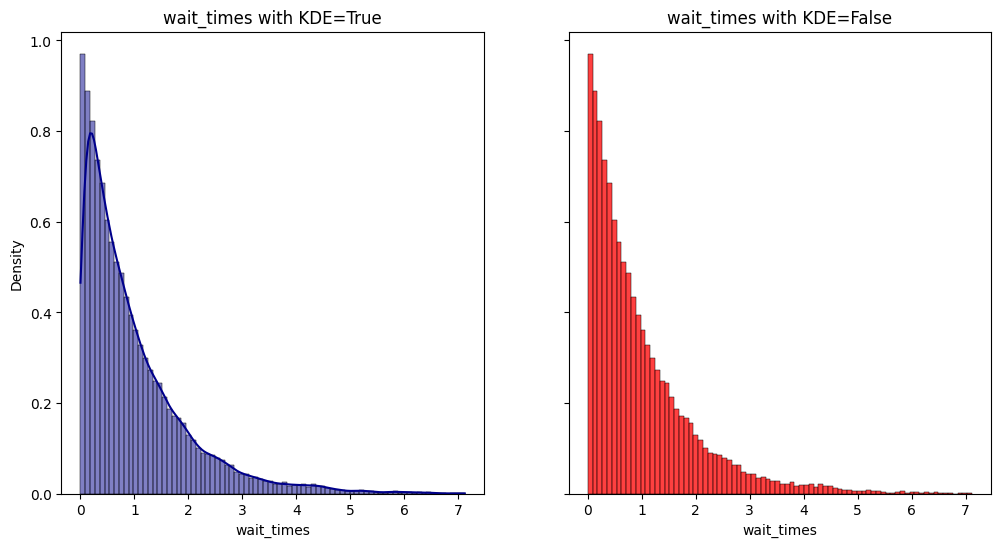

In [42]:
######################  TODO  ########################
# Distribution of Waiting Times
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.histplot(wait_times, bins=80, kde=1, color='darkblue', stat='density',ax=axes[0])  
axes[0].set_title('wait_times with KDE=True')
axes[0].set_xlabel('wait_times')  

sns.histplot(wait_times, bins=80, kde=0, color='red', stat='density',ax=axes[1])  
axes[1].set_title('wait_times with KDE=False')
axes[1].set_xlabel('wait_times')  
######################  TODO  ########################

Text(0.5, 0, 'service_times')

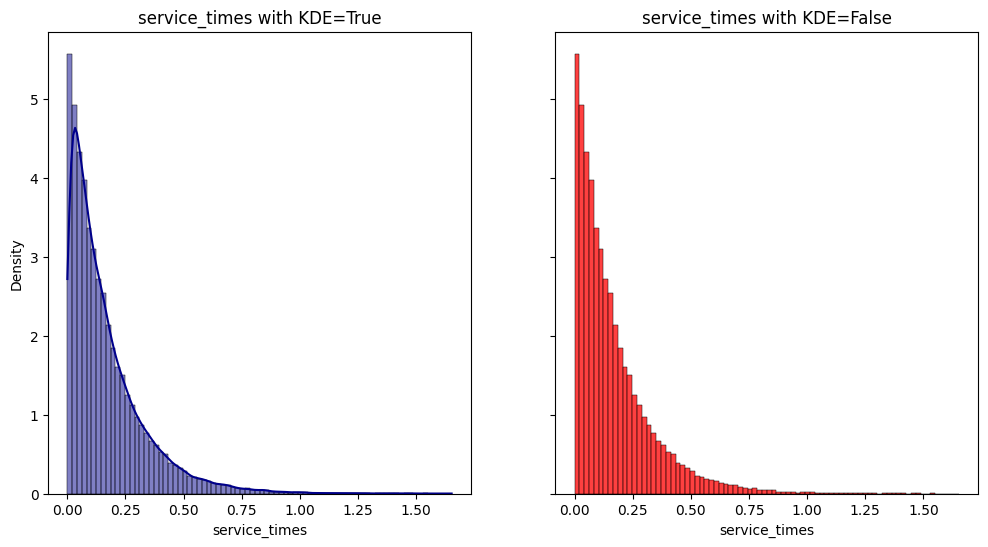

In [43]:
######################  TODO  ########################
# Distribution of Service Times
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.histplot(service_times, bins=80, kde=1, color='darkblue', stat='density',ax=axes[0])  
axes[0].set_title('service_times with KDE=True')
axes[0].set_xlabel('service_times')  

sns.histplot(service_times, bins=80, kde=0, color='red', stat='density',ax=axes[1])  
axes[1].set_title('service_times with KDE=False')
axes[1].set_xlabel('service_times')  
######################  TODO  ########################

# KDE یا Kernel Density Estimation

 
 یک روش غیرپارامتری برای تخمین تابع چگالی احتمال یک متغیر تصادفی است. این تکنیک به ویژه در آمار و احتمال برای تحلیل توزیع داده‌ها و درک بهتر رفتار متغیرهای تصادفی استفاده می‌شود.

### مفهوم KDE
به کمک آن می‌شود مجموعه ای از یک توزیع گسسته که پی‌دی‌اف آن را داریم، تبدیل به یک تابع چگالی احتمال پیوسته کرده و پی‌ام‌اف آن را داشته باشیم.

مقایسه نمودارها:
همان نمودار را می‌دهد ولی یک نوار پیوسته را نیز به نمودار اضافه کرده که اشاره به مفهوم کرنل دنسیتی استیمیشن دارد که توزیع گسسته را به یک توزیع پیوسته مشابه تبدیل می‌کند و می‌توان از آن در تحلیل‌های آماری بهره برد.

## Plot the Joint Distributions

**Note:** Use `sns.jointplot` to plot the joint distributions

Text(37.722222222222214, 0.5, 'service_times')

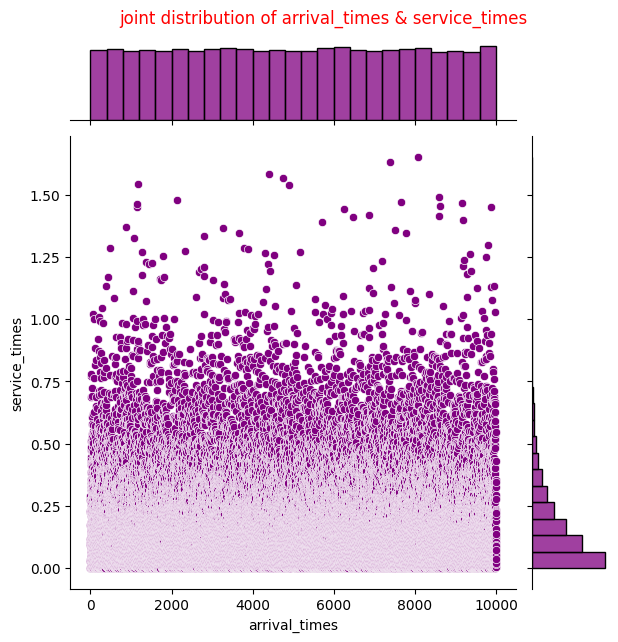

In [44]:
######################  TODO  ########################
# Joint Distribution of Arrival and Service Times
sns.jointplot(x=arrival_times, y=service_times, kind='scatter', color='purple', marginal_kws=dict(bins=25, fill=True))  
 
plt.suptitle('joint distribution of arrival_times & service_times' ,y=1.03 , color='red')  
plt.xlabel('arrival_times')  
plt.ylabel('service_times')  

######################  TODO  ########################

Text(37.722222222222214, 0.5, 'service_times')

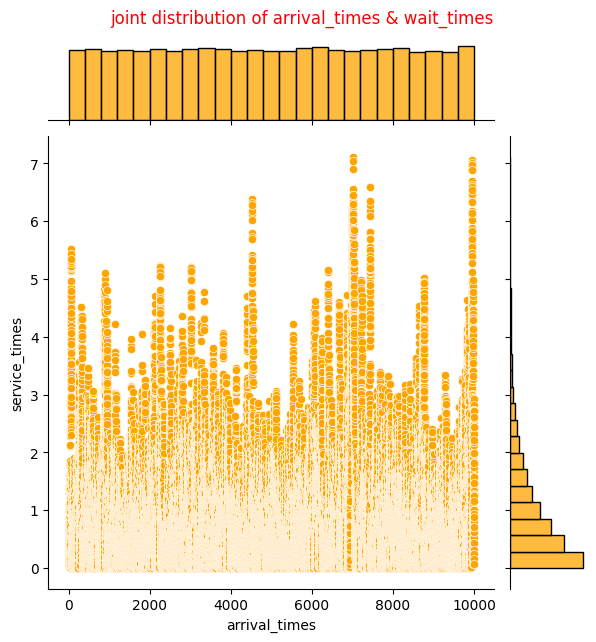

In [45]:
######################  TODO  ########################
# Joint Distribution of Arrival and Wait Times
sns.jointplot(x=arrival_times, y=wait_times, kind='scatter', color='orange', marginal_kws=dict(bins=25, fill=True))  
 
plt.suptitle('joint distribution of arrival_times & wait_times' ,y=1.03 , color='red')  
plt.xlabel('arrival_times')  
plt.ylabel('service_times')  

######################  TODO  ########################

## Analysis of Joint Distributions

TODO

## Scatter Plot and Correlation

Text(0, 0.5, 'service_times')

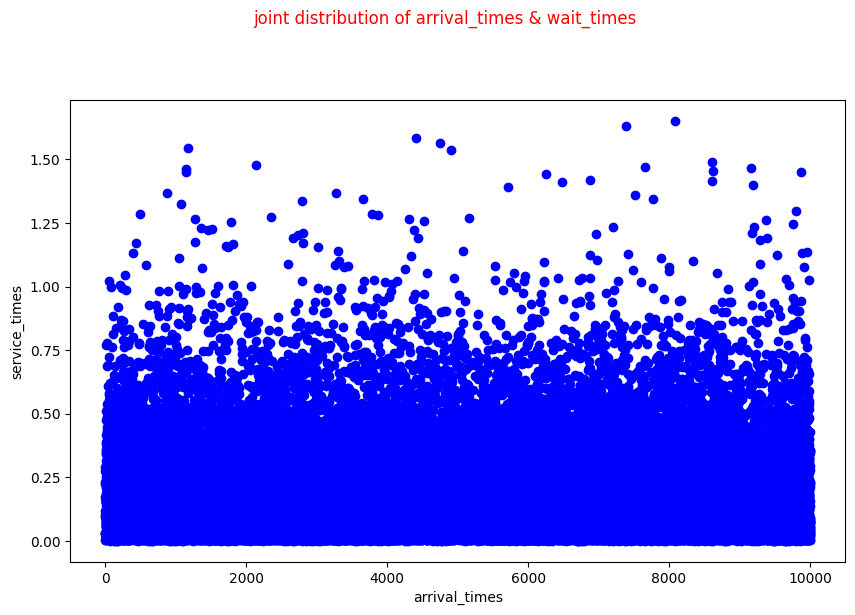

In [46]:
######################  TODO  ########################
# Scatter Plot of Arrival and Service Times
# W W W W W WW  W W WW  WW  WW  W W SHAK DARAM
#sns.jointplot(x=arrival_times, y=service_times, kind='scatter', color='blue', marginal_kws=dict(bins=25, fill=True))  
plt.figure(figsize=(10, 6))
plt.scatter(arrival_times, service_times, color='blue', marker='o', label='Data points')
plt.suptitle('joint distribution of arrival_times & wait_times' ,y=1.03 , color='red')  
plt.xlabel('arrival_times')  
plt.ylabel('service_times')  

######################  TODO  ########################

## Calculating `total_times`

hi
hi
hiii


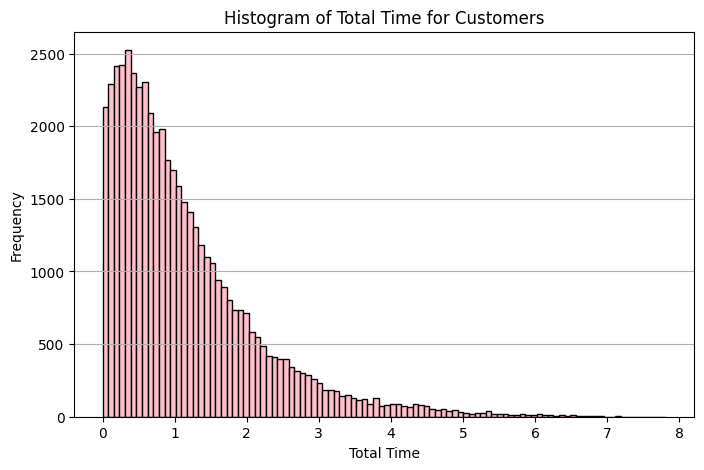

In [47]:
######################  TODO  ########################

###ndndnsnssjnjsnj kharab
# Distribution of Total Time Spent in the System
print('hi')
total_times = []   
pairs = zip(wait_times, service_times)  


for wait, service  in pairs:  

    total_time = wait + service 
    
    total_times.append(total_time)  

print('hi')

plt.figure(figsize=(8, 5)) 
plt.hist(total_times, bins=100, color='pink' , edgecolor='black')  
plt.xlabel('Total Time')  
plt.ylabel('Frequency')   
plt.title('Histogram of Total Time for Customers')  
plt.grid(axis='y')  

print('hiii')
######################  TODO  ########################

## Conditional Wait Times

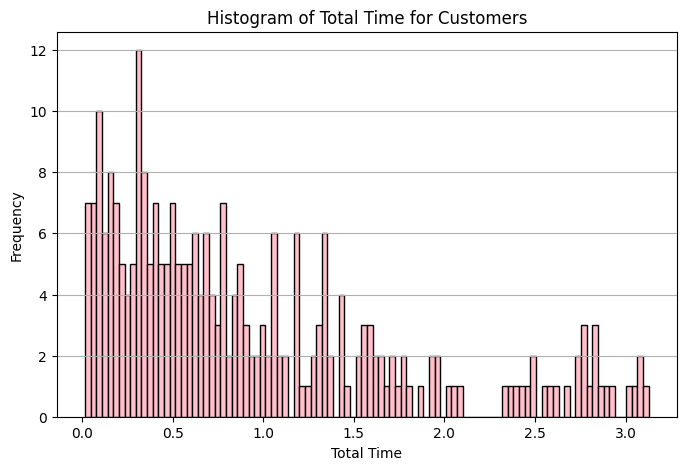

In [48]:
######################  TODO  ########################
# Conditional Distribution of Waiting Times (Arrival Time < 50)
filtered_wait_times = []  
filtered_total_times = []  

for j in range(len(arrival_times)):  
    if arrival_times[j] <= 49.999999999:   
        filtered_wait_times.append(wait_times[j])  
        new_total_time = wait_times[j] + service_times[j]  
        filtered_total_times.append(new_total_time)  

plt.figure(figsize=(8, 5)) 
plt.hist(filtered_total_times, bins=100, color='pink' , edgecolor='black')  
plt.xlabel('Total Time')  
plt.ylabel('Frequency')   
plt.title('Histogram of Total Time for Customers')  
plt.grid(axis='y')  

######################  TODO  ########################